Notebook 2 - Exploratory Data Analysis
Objective

This notebook explores the analytical dataset to answer key business questions regarding sales performance, customer behavior, logistics efficiency, and customer satisfaction. The findings will be used to support strategic business recommendations.

In [857]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_palette("Set2")

#### Load Dataset

In [858]:
df = pd.read_csv("../data/processed/olist_analytical_dataset.csv")
df.head()

,order_id,customer_unique_id,customer_city,customer_state,seller_city,seller_state,product_category_name_english,payment_type,payment_installments,payment_value,price,freight_value,order_value,review_score,review_category,delivery_time,delivery_delay,delivery_status,purchase_year,purchase_month,purchase_weekday,purchase_hour,purchase_quarter,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,credit_card,1.0,18.12,29.99,8.72,38.71,4.0,Good,8.0,-8.0,On Time,2017,10,Monday,10,Q4,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,voucher,1.0,2.00,29.99,8.72,38.71,4.0,Good,8.0,-8.0,On Time,2017,10,Monday,10,Q4,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,maua,SP,housewares,voucher,1.0,18.59,29.99,8.72,38.71,4.0,Good,8.0,-8.0,On Time,2017,10,Monday,10,Q4,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,barreiras,BA,belo horizonte,SP,perfumery,boleto,1.0,141.46,118.70,22.76,141.46,4.0,Good,13.0,-6.0,On Time,2018,7,Tuesday,20,Q3,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,guariba,SP,auto,credit_card,3.0,179.12,159.90,19.22,179.12,5.0,Excellent,9.0,-18.0,On Time,2018,8,Wednesday,8,Q3,2018-08


In [859]:
df["order_year_month"] = pd.to_datetime(df["order_year_month"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_city                  119143 non-null  object        
 3   customer_state                 119143 non-null  object        
 4   seller_city                    118310 non-null  object        
 5   seller_state                   118310 non-null  object        
 6   product_category_name_english  116576 non-null  object        
 7   payment_type                   119140 non-null  object        
 8   payment_installments           119140 non-null  float64       
 9   payment_value                  119140 non-null  float64       
 10  price                          118310 non-null  float64       
 11  

#### Visualization Functions

In [860]:
def currency_formatter(x, pos):
    return f"R$ {x:,.0f}"

In [861]:
def plot_bar(data, x, y, title, xlabel="", ylabel="", rotate=False):
    plt.figure(figsize=(10,5))
    ax = sns.barplot(data=data, x=x, y=y)
    ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if rotate:
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [862]:
def plot_line(data, x, y, title):
    plt.figure(figsize=(12,5))
    ax = plt.plot(
        data[x],
        data[y],
        marker="o",
        linewidth=2
    )

    plt.title(title, fontsize=14, weight="bold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [863]:
def plot_horizontal(data, x, y, title):
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=data,
        x=x,
        y=y
    )

    plt.title(title, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

#### Executive Overview

Business Question 1:
How many orders, customers, and total payments does Olist have?

Business Context
Understanding overall business performance provides management with a high-level overview of the company's operational scale before diving into detailed analyses.

In [864]:
summary = pd.DataFrame({
    "Metric":[
        "Total Orders",
        "Total Customers",
        "Total Payments",
        "Average Order Value",
        "Average Review Score"
    ],
    "Value":[
        df["order_id"].nunique(),
        df["customer_unique_id"].nunique(),
        df["payment_value"].sum(),
        df["payment_value"].sum()/df["order_id"].nunique(),
        df["review_score"].mean()
    ]
})
summary

,Metric,Value
0,Total Orders,9.944100e+04
1,Total Customers,9.609600e+04
2,Total Payments,2.057966e+07
3,Average Order Value,2.069535e+02
4,Average Review Score,4.015582e+00


#### Insight

This table provides a high-level snapshot of Olist's business performance, including transaction volume, customer base, payment value, and customer satisfaction.

These KPIs will serve as the baseline for further analyses in the following sections.

#### Business Question 2
How has Olist's business grown over time?

Business Context: 
Understanding transaction trends over time helps management identify business growth patterns, seasonality, and periods of significant change. This information is essential for strategic planning, forecasting, and evaluating business performance.

In [865]:
monthly_overview = (
    df.groupby("order_year_month")
      .agg(
          total_orders=("order_id", "nunique"),
          total_payment=("payment_value", "sum"),
          total_customers=("customer_unique_id", "nunique")
      )
      .reset_index()
)
monthly_overview.head()

,order_year_month,total_orders,total_payment,total_customers
0,2016-09-01,4,388.47,4
1,2016-10-01,324,76559.05,321
2,2016-12-01,1,19.62,1
3,2017-01-01,800,190806.27,765
4,2017-02-01,1780,351848.13,1755


In [866]:
monthly_overview

,order_year_month,total_orders,total_payment,total_customers
0,2016-09-01,4,388.47,4
1,2016-10-01,324,76559.05,321
2,2016-12-01,1,19.62,1
3,2017-01-01,800,190806.27,765
4,2017-02-01,1780,351848.13,1755
5,2017-03-01,2682,547769.84,2642
6,2017-04-01,2404,512126.52,2372
7,2017-05-01,3700,737425.31,3625
8,2017-06-01,3245,613777.41,3180
9,2017-07-01,4026,749242.84,3947


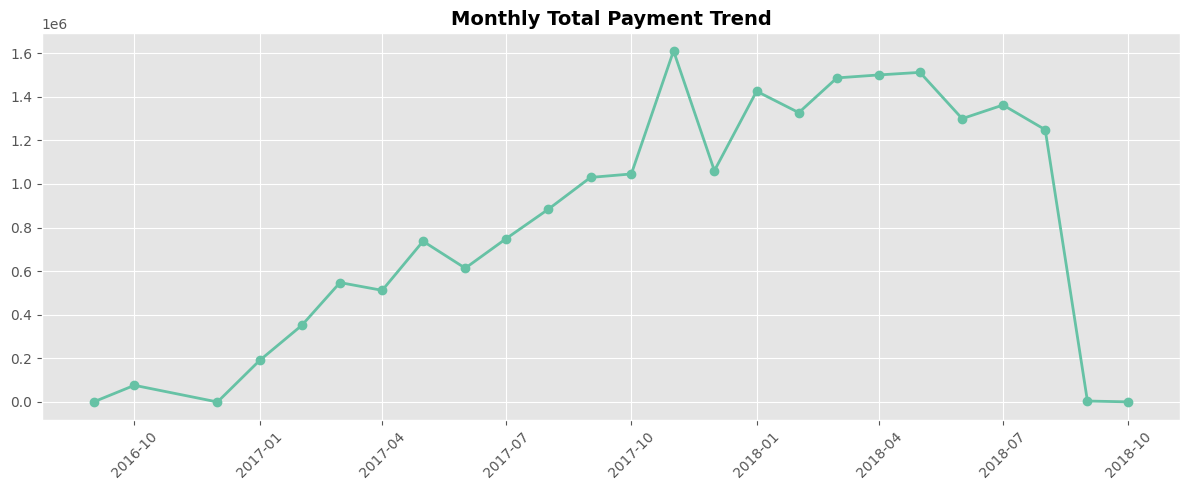

In [867]:
plot_line(
    data=monthly_overview,
    x="order_year_month",
    y="total_payment",
    title="Monthly Total Payment Trend"
)

#### Insight
The visualization illustrates how the total payment changed throughout the observation period. Growth trends, declines, and seasonal fluctuations can be identified from this timeline and will be further investigated in subsequent analyses.

#### Business Recommendation
- Monitor monthly business performance continuously.
- Identify periods with unusually high or low transactions.
- Use historical trends to support sales forecasting and marketing campaign planning.

#### Business Question 3
How has the number of orders changed over time?

Business Context: 
The number of orders reflects customer purchasing activity and overall marketplace demand. Monitoring order trends helps identify business growth and operational workload.

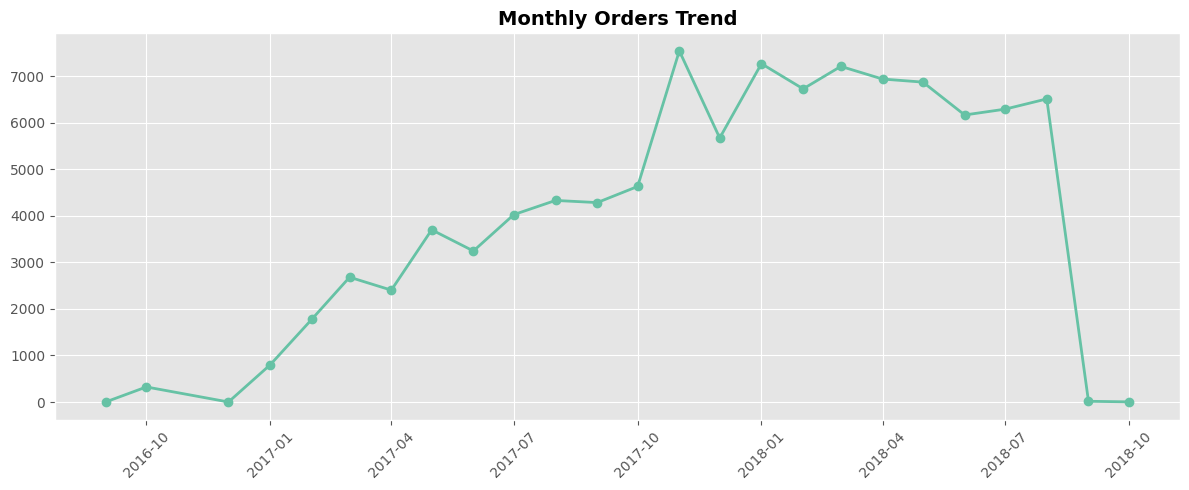

In [868]:
plot_line(
    data=monthly_overview,
    x="order_year_month",
    y="total_orders",
    title="Monthly Orders Trend"
)

#### Insight
The monthly order trend provides a clear view of customer purchasing activity. Comparing this trend with payment values helps determine whether business growth is driven by increasing order volume or higher transaction values.

#### Business Recommendation
- Investigate factors contributing to significant increases or decreases in monthly orders.
- Align inventory planning with historical order patterns.
- Evaluate promotional campaigns during high-performing months.

#### Business Question 4
How has the customer base grown over time?

Business Context:
Customer growth is one of the primary indicators of marketplace expansion. Monitoring customer acquisition helps evaluate marketing effectiveness and business scalability.

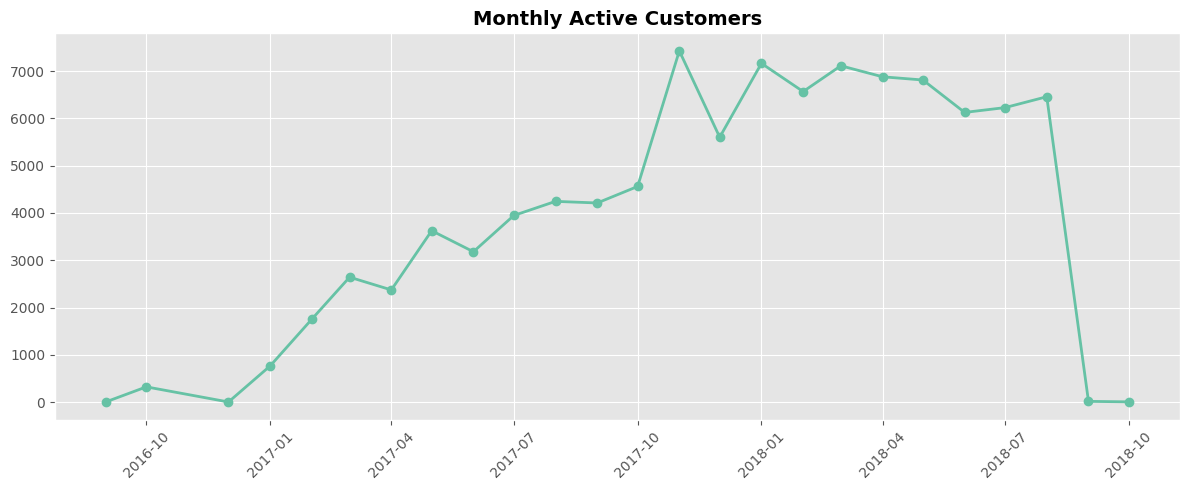

In [869]:
plot_line(
    data=monthly_overview,
    x="order_year_month",
    y="total_customers",
    title="Monthly Active Customers"
)

#### Insight
Monthly active customers indicate the marketplace's ability to attract purchasing customers. Comparing this metric with orders provides insights into purchasing frequency.

#### Business Recommendation
- Increase acquisition campaigns during slow-growth periods.
- Develop retention strategies to encourage repeat purchases.
- Monitor customer growth together with revenue performance.

#### Business Question 5
What are the key business performance indicators?

Business Context: 
Executives require concise KPI summaries to quickly assess business performance before conducting detailed analyses.

In [870]:
executive_kpi = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Total Customers",
        "Total Payment",
        "Average Order Value",
        "Average Review Score",
        "Average Delivery Time"
    ],
    "Value": [
        df["order_id"].nunique(),
        df["customer_unique_id"].nunique(),
        df["payment_value"].sum(),
        df["payment_value"].sum() / df["order_id"].nunique(),
        round(df["review_score"].mean(), 2),
        round(df["delivery_time"].mean(), 2)
    ]
})
executive_kpi

,KPI,Value
0,Total Orders,9.944100e+04
1,Total Customers,9.609600e+04
2,Total Payment,2.057966e+07
3,Average Order Value,2.069535e+02
4,Average Review Score,4.020000e+00
5,Average Delivery Time,1.202000e+01


#### Business Recommendation
Management should continuously monitor these KPIs through an executive dashboard to detect performance changes promptly and support data-driven decision making.

#### Helper Functions
The following helper functions are created to simplify repetitive analysis and visualization tasks throughout this project.

In [871]:
def create_monthly_summary(df, value_column):
    """
    Create monthly summary for a selected metric.
    """

    summary = (
        df.groupby("order_year_month")
        .agg(
            Value=(value_column, "sum")
        )
        .reset_index()
    )
    return summary

In [872]:
def create_monthly_unique(df, value_column):
    """
    Create monthly summary using unique count.
    """

    summary = (
        df.groupby("order_year_month")
        .agg(
            Value=(value_column, "nunique")
        )
        .reset_index()
    )
    return summary

In [873]:
def create_top_n(df, group_column, value_column, n=10):
    summary = (
        df.groupby(group_column)
        .agg(
            Value=(value_column, "sum")
        )
        .sort_values(
            by="Value",
            ascending=False
        )
        .head(n)
        .reset_index()
    )
    return summary

In [874]:
def create_count_summary(df, group_column):
    summary = (
        df[group_column]
        .value_counts()
        .reset_index()
    )
    summary.columns = [group_column, "Count"]
    return summary

In [875]:
def calculate_percentage(df, column):
    summary = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )
    summary.columns = [column, "Percentage"]
    return summary

In [876]:
def calculate_growth(df, column):
    growth = (
        df[column]
        .pct_change()
        .mul(100)
        .round(2)
    )
    return growth

In [877]:
def add_value_labels(ax):
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.0f",
            padding=3
        )

In [878]:
def plot_bar(
    data,
    x,
    y,
    title,
    xlabel="",
    ylabel="",
    rotate=False,
    currency=False
):

    plt.figure(figsize=(10,5))

    ax = sns.barplot(
        data=data,
        x=x,
        y=y
    )

    if currency:
        ax.yaxis.set_major_formatter(
            FuncFormatter(currency_formatter)
        )

    add_value_labels(ax)
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if rotate:
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [879]:
def plot_line(
    data,
    x,
    y,
    title,
    ylabel=""
):

    plt.figure(figsize=(12,5))

    plt.plot(
        data[x],
        data[y],
        marker="o",
        linewidth=2
    )

    plt.title(title, fontsize=14, weight="bold")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(alpha=.3)
    plt.tight_layout()
    plt.show()

In [880]:
def plot_horizontal(
    data,
    x,
    y,
    title,
    currency=False
):

    plt.figure(figsize=(10,6))

    ax = sns.barplot(
        data=data,
        x=x,
        y=y
    )

    if currency:
        ax.xaxis.set_major_formatter(
            FuncFormatter(currency_formatter)
        )

    add_value_labels(ax)
    plt.title(title, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

In [881]:
monthly_payment = create_monthly_summary(
    df,
    "payment_value"
)
monthly_payment.head()

,order_year_month,Value
0,2016-09-01,388.47
1,2016-10-01,76559.05
2,2016-12-01,19.62
3,2017-01-01,190806.27
4,2017-02-01,351848.13


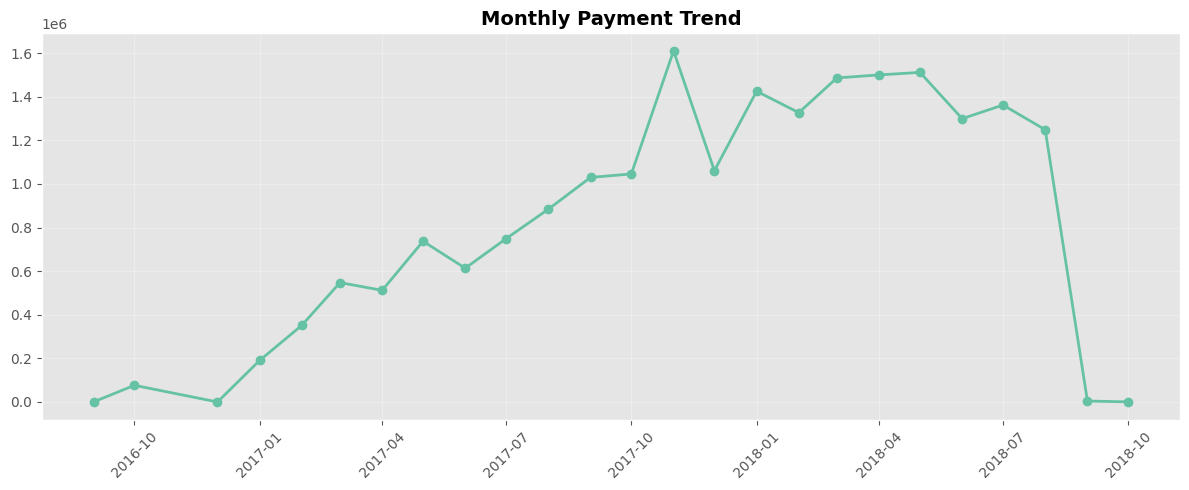

In [882]:
plot_line(
    monthly_payment,
    "order_year_month",
    "Value",
    "Monthly Payment Trend"
)

#### Sales Performance Analysis
Business Question 6: How has total payment changed over time?

Business Context:
Monitoring monthly payment trends helps management evaluate business growth, identify seasonality, and detect significant changes in customer purchasing behavior.

This analysis provides a foundation for future forecasting and strategic planning.

In [883]:
monthly_payment = create_monthly_summary(
    df,
    "payment_value"
)
monthly_payment.head()

,order_year_month,Value
0,2016-09-01,388.47
1,2016-10-01,76559.05
2,2016-12-01,19.62
3,2017-01-01,190806.27
4,2017-02-01,351848.13


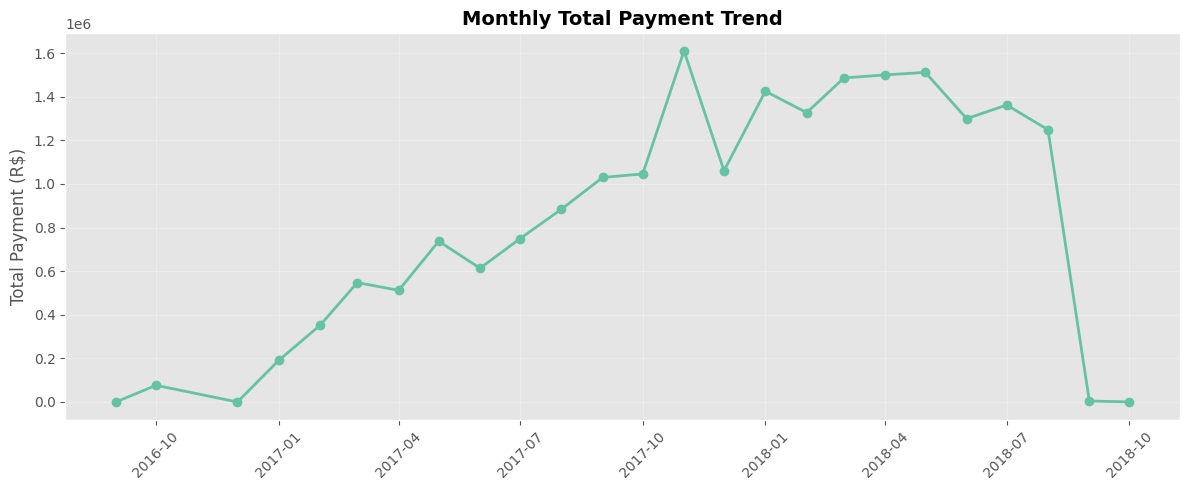

In [884]:
plot_line(
    data=monthly_payment,
    x="order_year_month",
    y="Value",
    title="Monthly Total Payment Trend",
    ylabel="Total Payment (R$)"
)

In [885]:
monthly_payment

,order_year_month,Value
0,2016-09-01,388.47
1,2016-10-01,76559.05
2,2016-12-01,19.62
3,2017-01-01,190806.27
4,2017-02-01,351848.13
5,2017-03-01,547769.84
6,2017-04-01,512126.52
7,2017-05-01,737425.31
8,2017-06-01,613777.41
9,2017-07-01,749242.84


#### Insight

The monthly payment trend indicates that Olist experienced steady business growth throughout the observed period, particularly from early 2017 to mid-2018.

A notable increase occurred during late 2017, with the highest total payment recorded in November 2017. This pattern suggests strong seasonal demand, likely influenced by major shopping events and year-end consumer spending.

After reaching its peak, monthly payment remained relatively stable during the first half of 2018 before declining sharply in September and October 2018. Since the dataset ends in October 2018, this decline most likely reflects incomplete monthly data rather than an actual decrease in business performance.

#### Business Recommendation
- Increase marketing campaigns during historically high-performing months such as November.
- Prepare inventory and logistics capacity before seasonal demand peaks.
- Exclude incomplete months when evaluating long-term business performance to avoid misleading conclusions.

#### Business Question 7
What is the month-over-month payment growth?

Business Context:
Payment growth helps evaluate whether the business is expanding consistently or experiencing fluctuations. Understanding growth patterns enables management to anticipate future business performance.

In [886]:
# Exclude incomplete months for growth analysis
monthly_payment_growth = monthly_payment[
    (monthly_payment["order_year_month"] >= "2017-01-01") &
    (monthly_payment["order_year_month"] <= "2018-08-01")
].copy()

monthly_payment_growth["Growth (%)"] = calculate_growth(
    monthly_payment_growth,
    "Value"
)
monthly_payment_growth

,order_year_month,Value,Growth (%)
3,2017-01-01,190806.27,NaN
4,2017-02-01,351848.13,84.40
5,2017-03-01,547769.84,55.68
6,2017-04-01,512126.52,-6.51
7,2017-05-01,737425.31,43.99
8,2017-06-01,613777.41,-16.77
9,2017-07-01,749242.84,22.07
10,2017-08-01,884168.36,18.01
11,2017-09-01,1030141.97,16.51
12,2017-10-01,1046083.41,1.55


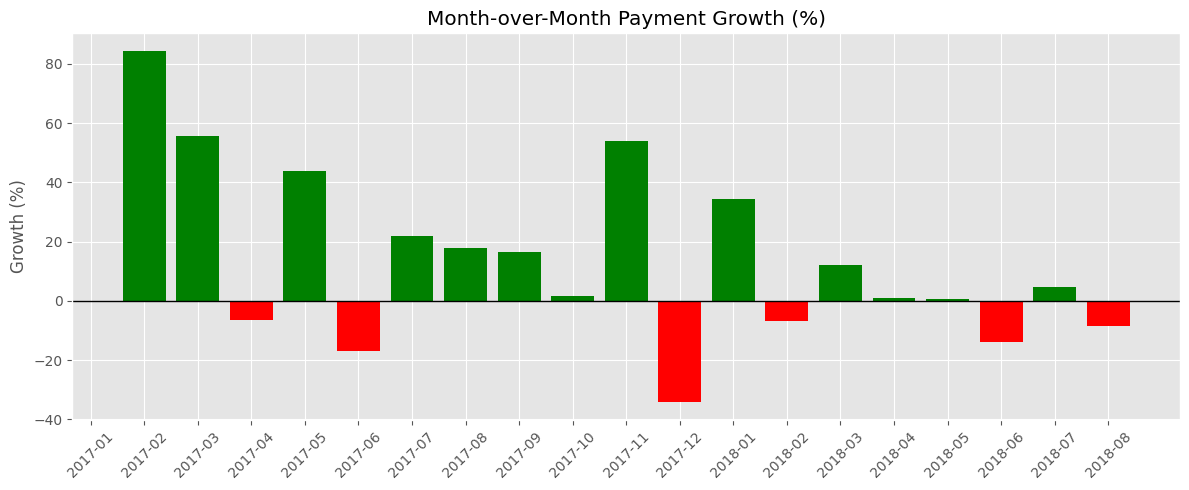

In [887]:
plt.figure(figsize=(12,5))

colors = [
    "green" if x >= 0 else "red"
    for x in monthly_payment_growth["Growth (%)"].fillna(0)
]

plt.bar(
    monthly_payment_growth["order_year_month"].dt.strftime("%Y-%m"),
    monthly_payment_growth["Growth (%)"],
    color=colors
)

plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45)
plt.title("Month-over-Month Payment Growth (%)")
plt.ylabel("Growth (%)")
plt.tight_layout()
plt.show()

#### Insight

After excluding incomplete months, the month-over-month payment growth shows a more stable business trend. Olist experienced several periods of positive growth during 2017 and early 2018, indicating increasing customer purchasing activity.

Although monthly fluctuations remain, the overall trend suggests consistent business expansion rather than irregular spikes caused by incomplete transactional data.

#### Business Recommendation
- Exclude incomplete periods when evaluating business growth to ensure accurate performance measurement.
- Continuously monitor month-over-month growth as an early indicator of changes in customer demand.
- Investigate months with significant positive or negative growth to identify successful campaigns or operational challenges.

#### Business Question 8
Which months generated the highest total payment?

Business Context:
Identifying top-performing months helps management understand seasonal demand and prepare future promotional campaigns.

In [888]:
top_months = (
    monthly_payment
    .sort_values(
        by="Value",
        ascending=False
    )
    .head(10)
)
top_months

,order_year_month,Value
13,2017-11-01,1610581.21
19,2018-05-01,1512010.75
18,2018-04-01,1500373.12
17,2018-03-01,1486669.64
15,2018-01-01,1425461.40
21,2018-07-01,1362267.08
16,2018-02-01,1327338.97
20,2018-06-01,1299683.17
22,2018-08-01,1248942.63
14,2017-12-01,1060949.63


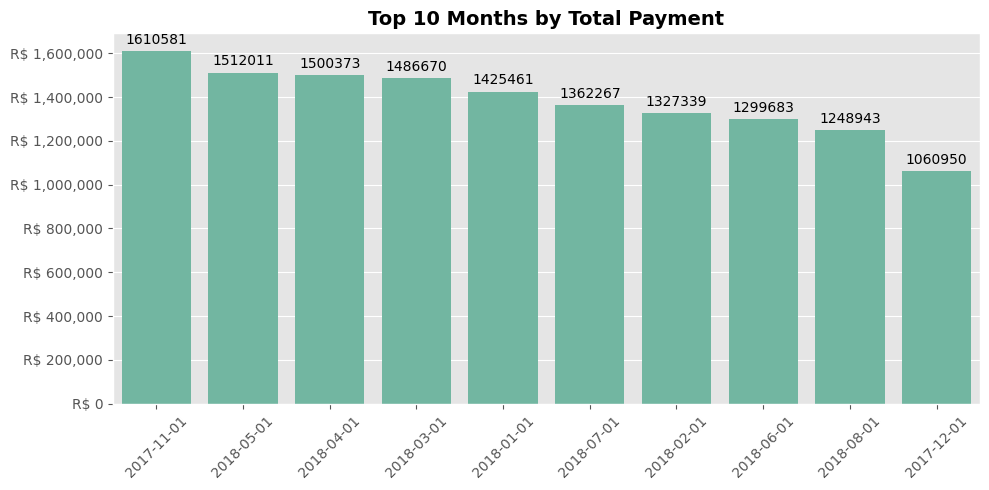

In [889]:
plot_bar(
    data=top_months,
    x="order_year_month",
    y="Value",
    title="Top 10 Months by Total Payment",
    rotate=True,
    currency=True
)

#### Insight

November 2017 generated the highest total payment, reaching approximately R$1.61 million. This indicates a strong seasonal sales peak, likely driven by large promotional campaigns and increased customer purchasing activity.

Several months in 2018 consistently appeared among the top-performing months, suggesting that Olist successfully maintained strong sales performance after the significant growth observed in late 2017.

#### Business Recommendation
- Allocate larger marketing budgets before historically high-performing months.
- Analyze successful campaigns from November 2017 and replicate effective strategies.
- Ensure sufficient inventory and logistics capacity during expected peak sales periods.

#### Business Question 9
How does total payment perform across quarters?

Business Context:
Quarterly performance provides a broader view of business trends and is commonly used in executive reporting and strategic planning.

In [890]:
quarterly_payment = (
    df.groupby("purchase_quarter")
    .agg(
        Total_Payment=("payment_value","sum")
    )
    .reset_index()
)
quarterly_payment

,purchase_quarter,Total_Payment
0,Q1,5329894.25
1,Q2,6175396.28
2,Q3,5279590.89
3,Q4,3794782.59


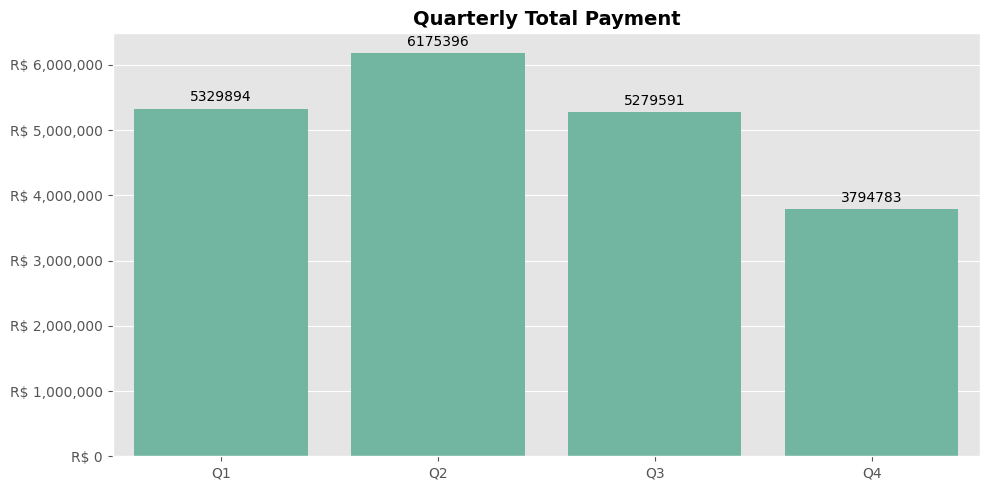

In [891]:
plot_bar(
    quarterly_payment,
    "purchase_quarter",
    "Total_Payment",
    "Quarterly Total Payment",
    currency=True
)

#### Insight

Quarter 2 recorded the highest total payment, exceeding R$6.17 million, indicating the strongest business performance during the observation period.

Although Quarter 4 shows the lowest total payment, this result should be interpreted carefully because the dataset only contains transactions until October 2018. Therefore, Quarter 4 represents an incomplete period and should not be directly compared with the other quarters.

#### Business Recommendation
- Focus sales and promotional strategies on maintaining the strong performance observed in Quarter 2.
- Avoid using incomplete quarterly data for strategic decision-making.
- Consider comparing only complete quarters when evaluating long-term business performance.

#### Business Question 10
What is the Average Order Value (AOV)?

#### Business Context:
Average Order Value (AOV) measures the average amount spent by customers in each order. This KPI helps businesses evaluate purchasing behavior and identify opportunities to increase revenue through cross-selling, upselling, and promotional strategies.

In [892]:
aov = (
    df.groupby("order_id")["payment_value"]
      .sum()
      .mean()
)

print(f"Average Order Value (AOV): R$ {aov:,.2f}")

Average Order Value (AOV): R$ 206.95


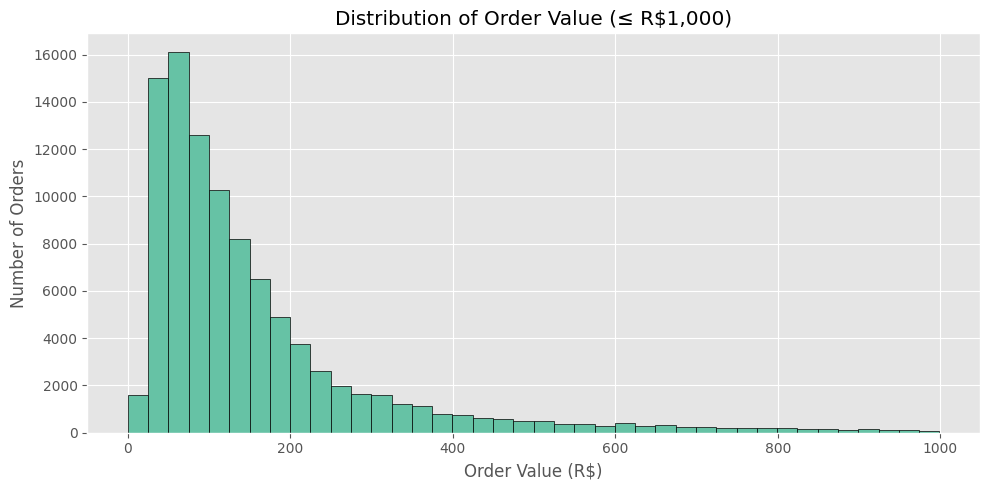

In [893]:
plt.figure(figsize=(10,5))

plt.hist(
    order_value_distribution[
        order_value_distribution <= 1000
    ],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Order Value (≤ R$1,000)")
plt.xlabel("Order Value (R$)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [894]:
order_value_distribution.describe()

count     99441.000000
mean        206.953510
std         622.550183
min           0.000000
25%          62.960000
50%         110.240000
75%         196.520000
max      109312.640000
Name: payment_value, dtype: float64

### Insight

The Average Order Value (AOV) is **R$206.95** per order. However, the order value distribution is highly right-skewed, indicating that most customers place relatively low-value orders while a small number of exceptionally large transactions significantly increase the overall average.

The median order value is only **R$110.24**, which is substantially lower than the mean. This suggests that the median better represents the typical customer transaction than the average.

### Business Recommendation
- Consider increasing the average basket size through cross-selling and upselling strategies.
- Design promotional campaigns such as free shipping thresholds or bundle discounts to encourage customers to spend more per transaction.
- Use both mean and median order values when evaluating customer purchasing behavior, as the average alone may be influenced by extreme transactions.

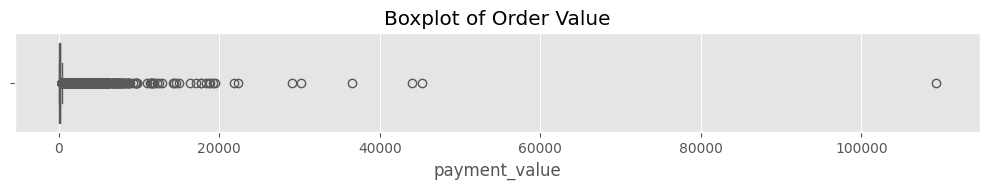

In [895]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=order_value_distribution
)

plt.title("Boxplot of Order Value")
plt.tight_layout()
plt.show()

#### Business Question 11
Which day of the week generates the highest total payment?

Business Context:
Understanding purchasing behavior by day of the week enables businesses to identify peak shopping days. These insights help optimize promotional campaigns, inventory planning, staffing, and operational efficiency.

In [896]:
weekday_payment = (
    df.groupby("purchase_weekday")
      .agg(
          Total_Payment=("payment_value", "sum"),
          Total_Orders=("order_id", "nunique")
      )
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_payment = (
    weekday_payment
    .reindex(weekday_order)
    .reset_index()
)
weekday_payment

,purchase_weekday,Total_Payment,Total_Orders
0,Monday,3347786.31,16196
1,Tuesday,3361564.89,15963
2,Wednesday,3198612.69,15552
3,Thursday,3145030.37,14761
4,Friday,3056608.65,14122
5,Saturday,2172171.12,10887
6,Sunday,2297889.98,11960


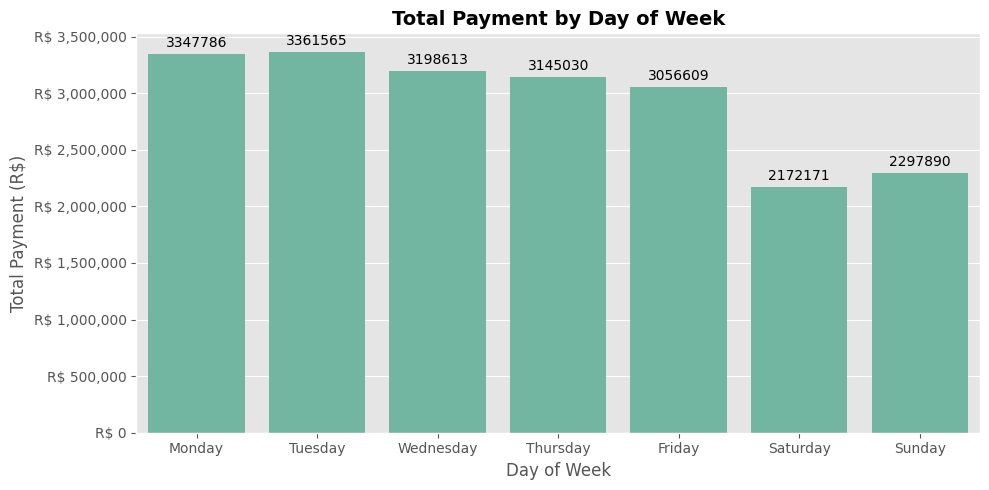

In [897]:
plot_bar(
    data=weekday_payment,
    x="purchase_weekday",
    y="Total_Payment",
    title="Total Payment by Day of Week",
    xlabel="Day of Week",
    ylabel="Total Payment (R$)",
    currency=True
)

#### Insight

Customer purchasing activity is consistently higher on weekdays than on weekends. Monday generated the highest total payment (approximately R$3.35 million), followed closely by Tuesday.

From Wednesday to Friday, total payment gradually declined, while a significant decrease occurred during the weekend, particularly on Saturday. This suggests that customers are more likely to complete purchases during working days rather than weekends.

#### Business Recommendation
- Schedule promotional campaigns on Monday and Tuesday to maximize customer engagement during peak purchasing periods.
- Launch weekend-exclusive promotions to stimulate transactions on Saturdays and Sundays.
- Align inventory planning and customer service resources with higher weekday transaction volumes.

#### Business Question 12
At what hour do customers make the most purchases?

Business Context:
Knowing the busiest purchasing hours helps businesses schedule promotional campaigns, customer service availability, and infrastructure capacity more effectively.

In [898]:
hourly_payment = (
    df.groupby("purchase_hour")
      .agg(
          Total_Payment=("payment_value", "sum"),
          Total_Orders=("order_id", "nunique")
      )
      .reset_index()
)
hourly_payment.head()

,purchase_hour,Total_Payment,Total_Orders
0,0,474801.20,2394
1,1,210304.96,1170
2,2,92701.68,510
3,3,51356.55,272
4,4,36004.52,206


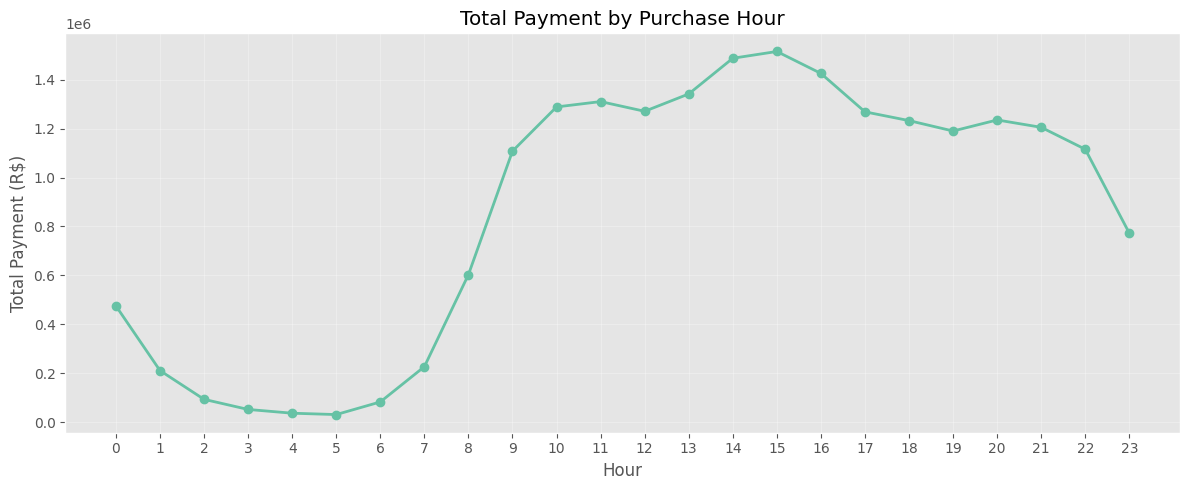

In [899]:
plt.figure(figsize=(12,5))

plt.plot(
    hourly_payment["purchase_hour"],
    hourly_payment["Total_Payment"],
    marker="o",
    linewidth=2
)

plt.xticks(range(24))
plt.title("Total Payment by Purchase Hour")
plt.xlabel("Hour")
plt.ylabel("Total Payment (R$)")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [900]:
hourly_payment

,purchase_hour,Total_Payment,Total_Orders
0,0,474801.20,2394
1,1,210304.96,1170
2,2,92701.68,510
3,3,51356.55,272
4,4,36004.52,206
5,5,30422.81,188
6,6,82144.98,502
7,7,226365.03,1231
8,8,602806.69,2967
9,9,1108161.14,4785


#### Insight

Customer purchasing activity is lowest during the early morning hours (02:00–06:00). Transaction value begins to increase rapidly after 08:00 and remains consistently high throughout the day.

The highest total payment occurs around 15:00, indicating that customers tend to complete purchases during standard working hours. Payment activity remains relatively stable until approximately 21:00 before declining at night.

#### Business Recommendation
- Schedule flash sales and marketing campaigns between 13:00 and 16:00 to maximize customer reach.
- Ensure system availability and customer support during peak transaction hours.
- Consider running targeted promotions during low-activity hours only if the objective is to increase off-peak engagement.

#### Business Question 13
Which payment methods are most preferred by customers?

Business Context:
Understanding customer payment preferences helps businesses optimize payment services, reduce transaction friction, and improve customer experience.

In [901]:
payment_method = (
    df.groupby("payment_type")
      .agg(
          Total_Payment=("payment_value","sum"),
          Total_Orders=("order_id","nunique")
      )
      .sort_values(
          by="Total_Payment",
          ascending=False
      )
      .reset_index()
)
payment_method

,payment_type,Total_Payment,Total_Orders
0,credit_card,15775450.54,76505
1,boleto,4110920.74,19784
2,voucher,435917.84,3866
3,debit_card,257374.89,1528
4,not_defined,0.00,3


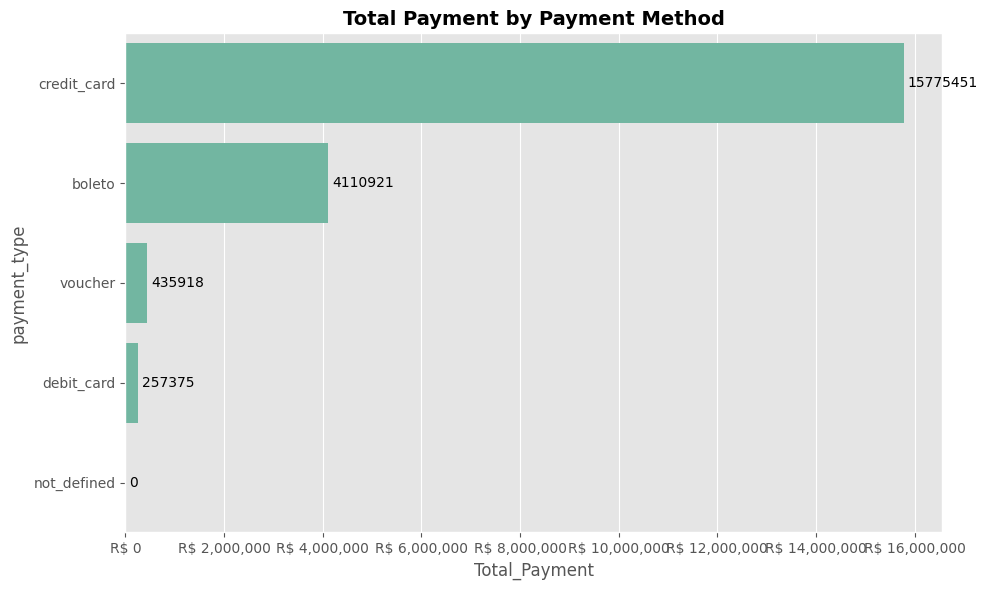

In [902]:
plot_horizontal(
    payment_method,
    "Total_Payment",
    "payment_type",
    "Total Payment by Payment Method",
    currency=True
)

#### Insight

Credit cards dominate customer payment preferences, contributing more than three-quarters of the total payment value. Boleto ranks as the second most popular payment method but generates significantly lower payment volume.

Voucher and debit card transactions account for only a small proportion of total payments, while transactions with undefined payment methods are negligible.

#### Business Recommendation
- Continue optimizing the credit card payment experience, as it represents the primary transaction channel.
- Explore promotional partnerships with credit card providers to increase customer spending.
- Evaluate strategies to encourage the adoption of alternative payment methods, reducing dependency on a single payment channel.

#### Customer Behavior Analysis
Business Question 14: Which states have the highest number of customers?

Business Context:
Customer distribution by state helps identify the company's strongest markets. This information supports regional marketing strategies, logistics planning, and future business expansion.

In [903]:
customer_state = (
    df.groupby("customer_state")
      .agg(
          Total_Customers=("customer_unique_id", "nunique"),
          Total_Orders=("order_id", "nunique"),
          Total_Payment=("payment_value", "sum")
      )
      .sort_values(
          by="Total_Customers",
          ascending=False
      )
      .reset_index()
)
customer_state.head(10)

,customer_state,Total_Customers,Total_Orders,Total_Payment
0,SP,40302,41746,7726078.35
1,RJ,12384,12852,2795615.67
2,MG,11259,11635,2351221.09
3,RS,5277,5466,1160175.66
4,PR,4882,5045,1079795.49
5,SC,3534,3637,801276.45
6,BA,3277,3380,805070.98
7,DF,2075,2140,438095.32
8,ES,1964,2033,408611.64
9,GO,1952,2020,520481.65


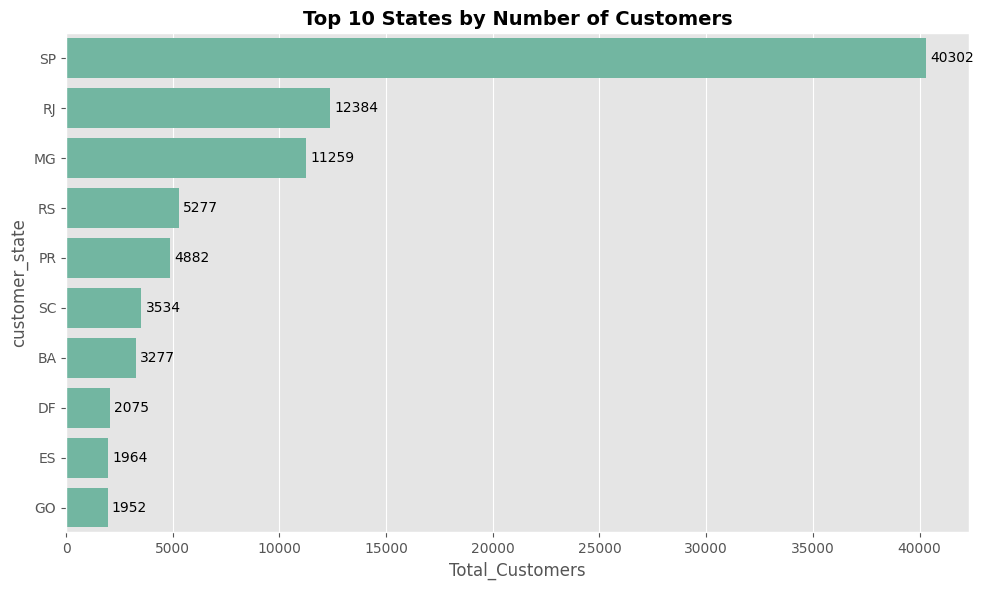

In [904]:
top_customer_state = customer_state.head(10)

plot_horizontal(
    data=top_customer_state,
    x="Total_Customers",
    y="customer_state",
    title="Top 10 States by Number of Customers"
)

In [905]:
top_customer_state

,customer_state,Total_Customers,Total_Orders,Total_Payment
0,SP,40302,41746,7726078.35
1,RJ,12384,12852,2795615.67
2,MG,11259,11635,2351221.09
3,RS,5277,5466,1160175.66
4,PR,4882,5045,1079795.49
5,SC,3534,3637,801276.45
6,BA,3277,3380,805070.98
7,DF,2075,2140,438095.32
8,ES,1964,2033,408611.64
9,GO,1952,2020,520481.65


#### Insight

São Paulo (SP) dominates Olist's customer base with **40,302 unique customers**, accounting for a substantially larger market than any other state. Rio de Janeiro (RJ) and Minas Gerais (MG) follow in second and third place, while the remaining states contribute considerably fewer customers.

This indicates that Olist's customer base is highly concentrated in Brazil's southeastern region, suggesting that the marketplace has established a particularly strong presence in these economically active areas.

#### Business Recommendation
- Continue strengthening customer retention programs in São Paulo, Rio de Janeiro, and Minas Gerais, as these regions represent Olist's core market.
- Explore expansion opportunities in states with lower customer penetration through localized marketing campaigns.
- Prioritize logistics infrastructure and customer service resources in high-density customer regions to maintain service quality.

#### Business Question 15
Which cities have the highest number of customers?

Business Context:
Identifying cities with the largest customer base helps businesses prioritize local marketing campaigns and operational investments.

In [906]:
customer_city = (
    df.groupby("customer_city")
      .agg(
          Total_Customers=("customer_unique_id","nunique"),
          Total_Orders=("order_id","nunique"),
          Total_Payment=("payment_value","sum")
      )
      .sort_values(
          by="Total_Customers",
          ascending=False
      )
      .head(15)
      .reset_index()
)
customer_city

,customer_city,Total_Customers,Total_Orders,Total_Payment
0,sao paulo,14984,15540,2901789.67
1,rio de janeiro,6620,6882,1581736.07
2,belo horizonte,2672,2773,509165.81
3,brasilia,2069,2131,435971.02
4,curitiba,1465,1521,333582.09
5,campinas,1398,1444,272595.57
6,porto alegre,1326,1379,317995.72
7,salvador,1209,1245,291499.12
8,guarulhos,1153,1189,207174.47
9,sao bernardo do campo,908,938,152128.20


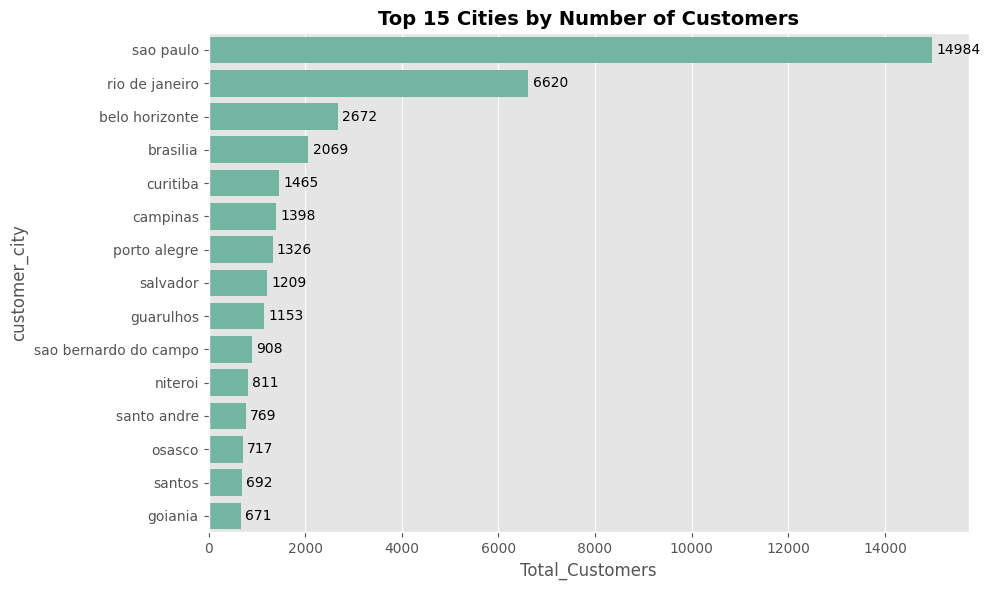

In [907]:
plot_horizontal(
    customer_city,
    "Total_Customers",
    "customer_city",
    "Top 15 Cities by Number of Customers"
)

#### Insight

São Paulo city has the largest customer base with **14,984 customers**, more than twice the number of Rio de Janeiro. Belo Horizonte, Brasília, and Curitiba also contribute significantly but remain far below São Paulo.

The results indicate that major metropolitan areas are Olist's primary customer hubs, highlighting the importance of urban markets in driving marketplace growth.

#### Business Recommendation
- Prioritize marketing investments in major metropolitan areas where customer density is highest.
- Develop city-specific promotional campaigns tailored to local customer preferences.
- Identify successful strategies implemented in São Paulo and adapt them to other large cities with growth potential.

#### Business Question 16
Which states generate the highest total payment?

Business Context:
A large customer base does not always translate into the highest revenue. Evaluating total payment by state helps identify the company's most valuable regional markets.

In [908]:
state_payment = (
    df.groupby("customer_state")
      .agg(
          Total_Payment=("payment_value","sum")
      )
      .sort_values(
          by="Total_Payment",
          ascending=False
      )
      .head(10)
      .reset_index()
)
state_payment

,customer_state,Total_Payment
0,SP,7726078.35
1,RJ,2795615.67
2,MG,2351221.09
3,RS,1160175.66
4,PR,1079795.49
5,BA,805070.98
6,SC,801276.45
7,GO,520481.65
8,DF,438095.32
9,ES,408611.64


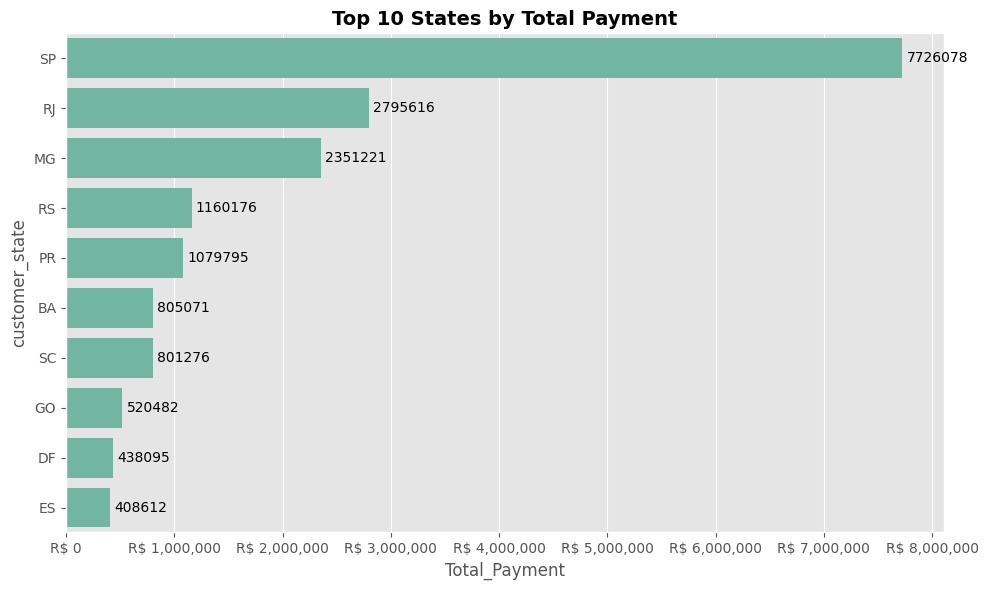

In [909]:
plot_horizontal(
    state_payment,
    "Total_Payment",
    "customer_state",
    "Top 10 States by Total Payment",
    currency=True
)

#### Insight

São Paulo generated the highest total payment, contributing approximately **R$7.73 million**, significantly outperforming every other state. Rio de Janeiro and Minas Gerais ranked second and third, maintaining the same regional dominance observed in customer distribution.

The consistency between customer concentration and payment contribution indicates that southeastern Brazil represents Olist's most valuable market, both in terms of customer volume and business revenue.

#### Business Recommendation
- Continue investing in customer acquisition and retention initiatives within São Paulo, Rio de Janeiro, and Minas Gerais.
- Evaluate opportunities to increase customer spending in lower-performing regions through targeted promotions and localized product offerings.
- Use the performance of southeastern states as a benchmark for future regional expansion strategies.

### Customer Segmentation (RFM Analysis)

Business Question 17: Which customer segments contribute the most to Olist's business?

Business Context:
Not all customers contribute equally to business performance. RFM (Recency, Frequency, Monetary) analysis helps identify valuable customer segments and supports customer retention and personalized marketing strategies.

In [910]:
snapshot_date = df["order_year_month"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2018-10-02 00:00:00')

In [911]:
rfm = (
    df.groupby("customer_unique_id")
      .agg(
          Recency=("order_year_month",
                   lambda x: (snapshot_date - x.max()).days),
          Frequency=("order_id", "nunique"),
          Monetary=("payment_value", "sum")
      )
      .reset_index()
)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,154,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,154,1,27.19
2,0000f46a3911fa3c0805444483337064,580,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,366,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,335,1,196.89


In [912]:
rfm.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,287.608506,1.034809,214.157343
std,153.623145,0.214384,644.891987
min,1.000000,1.000000,0.000000
25%,154.000000,1.000000,64.000000
50%,274.000000,1.000000,113.340000
75%,396.000000,1.000000,203.422500
max,761.000000,17.000000,109312.640000


In [913]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [914]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,154,1,141.90,5,1,4,514
1,0000b849f77a49e4a4ce2b2a4ca5be3f,154,1,27.19,5,1,1,511
2,0000f46a3911fa3c0805444483337064,580,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,366,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,335,1,196.89,2,1,4,214


In [915]:
def segment_customer(row):
    score = (
        int(row["R_Score"]) +
        int(row["F_Score"]) +
        int(row["M_Score"])
    )

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "Need Attention"

    else:
        return "At Risk"

rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,154,1,141.90,5,1,4,514,Loyal Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,154,1,27.19,5,1,1,511,Need Attention
2,0000f46a3911fa3c0805444483337064,580,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,366,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,335,1,196.89,2,1,4,214,Need Attention


In [916]:
segment_summary = (
    rfm["Segment"]
      .value_counts()
      .reset_index()
)

segment_summary.columns = [
    "Segment",
    "Customers"
]

segment_summary

,Segment,Customers
0,Loyal Customers,32913
1,Potential Loyalists,27681
2,Need Attention,18563
3,Champions,9084
4,At Risk,7855


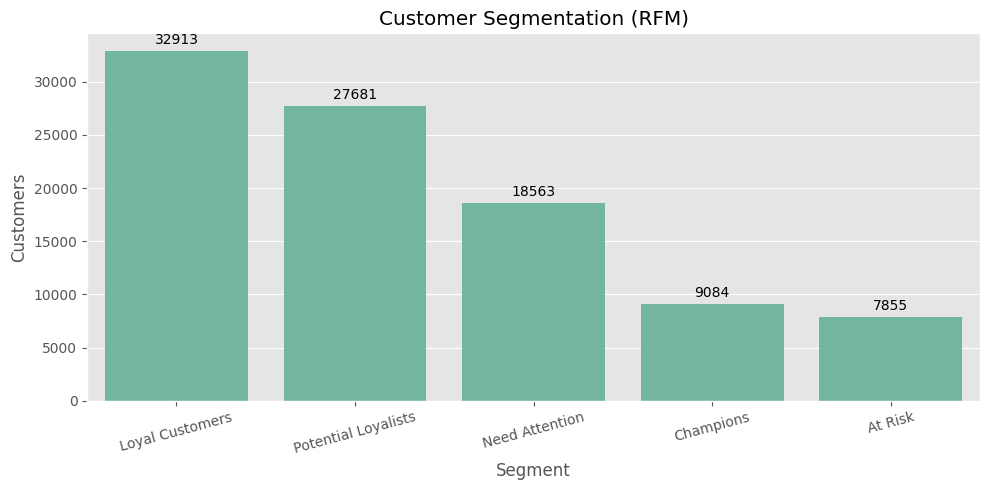

In [917]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=segment_summary,
    x="Segment",
    y="Customers"
)

add_value_labels(ax)
plt.title("Customer Segmentation (RFM)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Insight

RFM analysis shows that **Loyal Customers** represent the largest customer segment, accounting for **32,913 customers**, followed by **Potential Loyalists** with **27,681 customers**.

This indicates that Olist has successfully retained a large proportion of active customers while also maintaining a significant number of customers with the potential to become loyal buyers. However, there are still **18,563 customers** classified as **Need Attention** and **7,855 customers** categorized as **At Risk**, suggesting opportunities to improve customer retention and reduce churn.

Additionally, **9,084 customers** are classified as **Champions**, representing the company's most valuable customers who contribute significantly to business performance.

#### Business Recommendation
- Develop exclusive loyalty programs and personalized rewards to retain **Champions** and **Loyal Customers**.
- Implement targeted marketing campaigns for **Potential Loyalists** to encourage more frequent purchases.
- Launch re-engagement campaigns, personalized discounts, or reminder emails for **Need Attention** and **At Risk** customers to reduce customer churn.
- Continuously monitor customer segments through RFM analysis to evaluate the effectiveness of retention strategies.

### Pareto Analysis (80/20 Rule)
Business Question 18: Do a small percentage of customers contribute the majority of total revenue?

Business Context:
Businesses often observe that a relatively small proportion of customers generate the majority of revenue. Identifying this distribution helps prioritize customer retention strategies and resource allocation.

In [918]:
customer_revenue = (
    df.groupby("customer_unique_id")
      .agg(
          Revenue=("payment_value", "sum")
      )
      .sort_values(
          by="Revenue",
          ascending=False
      )
      .reset_index()
)
customer_revenue.head()

,customer_unique_id,Revenue
0,0a0a92112bd4c708ca5fde585afaa872,109312.64
1,698e1cf81d01a3d389d96145f7fa6df8,45256.00
2,c402f431464c72e27330a67f7b94d4fb,44048.00
3,4007669dec559734d6f53e029e360987,36489.24
4,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00


In [919]:
customer_revenue["Cumulative Revenue"] = (
    customer_revenue["Revenue"].cumsum()
)

customer_revenue["Revenue %"] = (
    customer_revenue["Cumulative Revenue"] /
    customer_revenue["Revenue"].sum()
) * 100

customer_revenue["Customer %"] = (
    np.arange(1, len(customer_revenue)+1)
    / len(customer_revenue)
) * 100

customer_revenue.head()

,customer_unique_id,Revenue,Cumulative Revenue,Revenue %,Customer %
0,0a0a92112bd4c708ca5fde585afaa872,109312.64,109312.64,0.531168,0.001041
1,698e1cf81d01a3d389d96145f7fa6df8,45256.00,154568.64,0.751075,0.002081
2,c402f431464c72e27330a67f7b94d4fb,44048.00,198616.64,0.965111,0.003122
3,4007669dec559734d6f53e029e360987,36489.24,235105.88,1.142418,0.004163
4,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00,265291.88,1.289097,0.005203


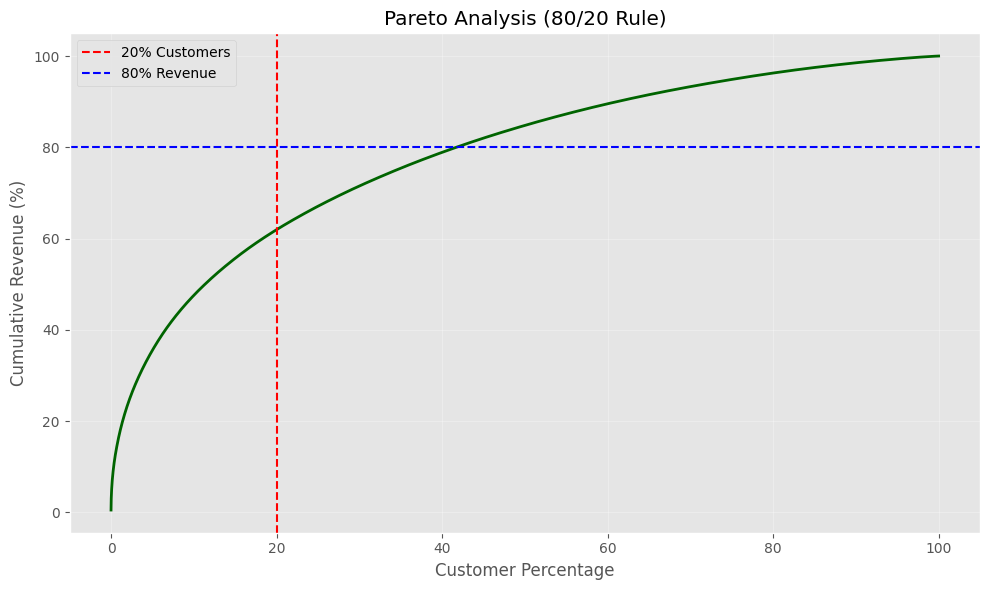

In [920]:
plt.figure(figsize=(10,6))

plt.plot(
    customer_revenue["Customer %"],
    customer_revenue["Revenue %"],
    linewidth=2,
    color="darkgreen"
)

plt.axvline(
    20,
    color="red",
    linestyle="--",
    label="20% Customers"
)

plt.axhline(
    80,
    color="blue",
    linestyle="--",
    label="80% Revenue"
)

plt.xlabel("Customer Percentage")
plt.ylabel("Cumulative Revenue (%)")
plt.title("Pareto Analysis (80/20 Rule)")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

In [921]:
pareto_20 = customer_revenue[
    customer_revenue["Customer %"] <= 20
]

pareto_result = pd.DataFrame({
    "Metric":[
        "Top 20% Customers Revenue Contribution"
    ],
    "Value":[
        pareto_20["Revenue"].sum() /
        customer_revenue["Revenue"].sum() * 100
    ]
})

pareto_result

,Metric,Value
0,Top 20% Customers Revenue Contribution,61.951542


#### Insight

The Pareto analysis shows that the top 20% of customers contribute approximately **61.95% of total revenue**. While a relatively small group of customers generates a significant share of revenue, Olist does not fully follow the traditional 80/20 Pareto principle.

This suggests that revenue is more evenly distributed across the customer base, indicating that Olist is not overly dependent on a small number of high-value customers. Such a distribution reduces business risk while highlighting the importance of maintaining a broad and active customer base.

#### Business Recommendation
- Continue investing in customer acquisition to maintain a diversified revenue base.
- Develop loyalty programs to encourage medium-value customers to become high-value customers.
- Prioritize retention strategies for top-spending customers while continuing to engage the broader customer population.

### Customer Lifetime Value (CLV)
Business Question 19: What is the estimated Customer Lifetime Value (CLV)?

Business Context:
Customer Lifetime Value estimates the long-term revenue generated by each customer. Understanding CLV helps businesses identify high-value customers and optimize customer acquisition and retention strategies.

In [922]:
clv = (
    df.groupby("customer_unique_id")
      .agg(
          Total_Revenue=("payment_value", "sum"),
          Total_Orders=("order_id", "nunique")
      )
      .reset_index()
)

clv["Average_Order_Value"] = (
    clv["Total_Revenue"] /
    clv["Total_Orders"]
)
clv.head()

,customer_unique_id,Total_Revenue,Total_Orders,Average_Order_Value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89


In [923]:
clv.describe()

,Total_Revenue,Total_Orders,Average_Order_Value
count,96096.000000,96096.000000,96096.000000
mean,214.157343,1.034809,206.066785
std,644.891987,0.214384,619.050852
min,0.000000,1.000000,0.000000
25%,64.000000,1.000000,63.270000
50%,113.340000,1.000000,111.020000
75%,203.422500,1.000000,196.360000
max,109312.640000,17.000000,109312.640000


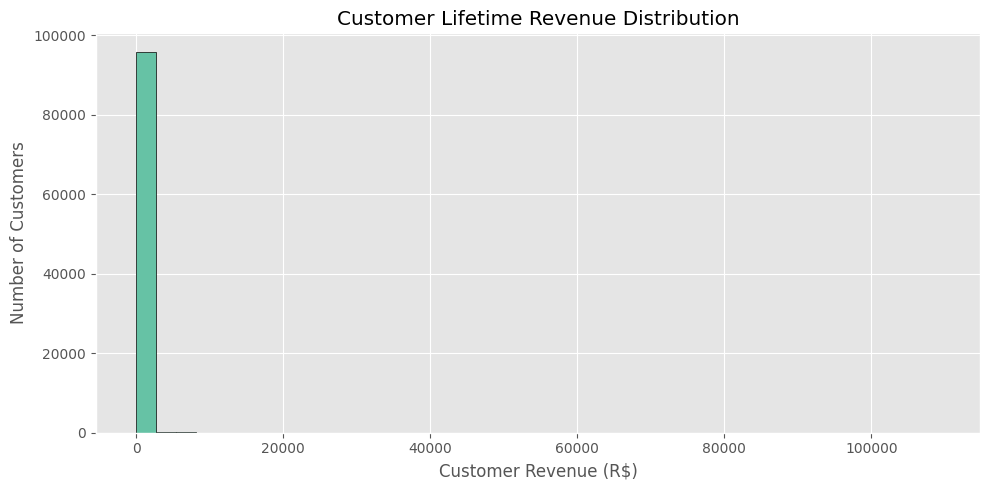

In [924]:
plt.figure(figsize=(10,5))

plt.hist(
    clv["Total_Revenue"],
    bins=40,
    edgecolor="black"
)

plt.title("Customer Lifetime Revenue Distribution")
plt.xlabel("Customer Revenue (R$)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [925]:
top_customer = (
    clv.sort_values(
        by="Total_Revenue",
        ascending=False
    )
    .head(10)
)
top_customer

,customer_unique_id,Total_Revenue,Total_Orders,Average_Order_Value
3826,0a0a92112bd4c708ca5fde585afaa872,109312.64,1,109312.640
39720,698e1cf81d01a3d389d96145f7fa6df8,45256.00,1,45256.000
73664,c402f431464c72e27330a67f7b94d4fb,44048.00,1,44048.000
24121,4007669dec559734d6f53e029e360987,36489.24,1,36489.240
90000,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00,1,30186.000
44447,763c8b1c9c68a0229c42c9fc6f662b93,29099.52,1,29099.520
75269,c8460e4251689ba205045f3ea17884a1,27935.46,4,6983.865
88262,eae0a83d752b1dd32697e0e7b4221656,25051.89,2,12525.945
23071,3d47f4368ccc8e1bb4c4a12dbda7111b,22346.60,1,22346.600
65407,adfa1cab2b2c8706db21bb13c0a1beb1,19457.04,1,19457.040


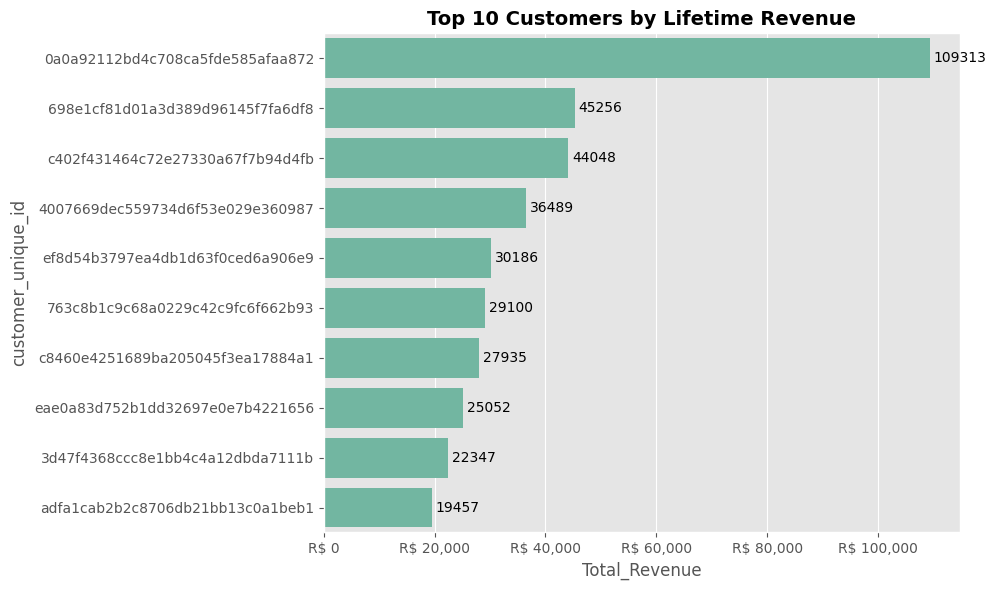

In [926]:
plot_horizontal(
    top_customer,
    "Total_Revenue",
    "customer_unique_id",
    "Top 10 Customers by Lifetime Revenue",
    currency=True
)

#### Insight

The average Customer Lifetime Value (CLV) is approximately **R$214.16** per customer, with an average of **1.03 orders** per customer. This indicates that most customers make only a single purchase during the observation period.

The customer revenue distribution is highly right-skewed, where the majority of customers contribute relatively low lifetime revenue, while a small number of customers generate exceptionally high revenue. The highest-value customer contributed more than **R$109,000**, illustrating the presence of a small group of premium customers.

#### Business Recommendation
- Increase customer retention through loyalty programs to encourage repeat purchases.
- Identify high-value customers and provide personalized offers or premium services.
- Develop re-engagement campaigns for one-time buyers to improve Customer Lifetime Value over time.
- Monitor CLV regularly as a key performance indicator for customer relationship management.

### Correlation Analysis
Business Question 20: Which business variables are correlated?

Business Context:
Understanding relationships between key business metrics helps identify factors that influence customer satisfaction, pricing, logistics performance, and overall business outcomes.

In [927]:
correlation_df = df[
    [
        "price",
        "freight_value",
        "payment_value",
        "order_value",
        "delivery_time",
        "delivery_delay",
        "review_score"
    ]
]

correlation_df.head()

,price,freight_value,payment_value,order_value,delivery_time,delivery_delay,review_score
0,29.99,8.72,18.12,38.71,8.0,-8.0,4.0
1,29.99,8.72,2.00,38.71,8.0,-8.0,4.0
2,29.99,8.72,18.59,38.71,8.0,-8.0,4.0
3,118.70,22.76,141.46,141.46,13.0,-6.0,4.0
4,159.90,19.22,179.12,179.12,9.0,-18.0,5.0


In [928]:
corr = correlation_df.corr(
    numeric_only=True
)

corr

,price,freight_value,payment_value,order_value,delivery_time,delivery_delay,review_score
price,1.000000,0.415938,0.739236,0.997160,0.061389,-0.003150,-0.004492
freight_value,0.415938,1.000000,0.373762,0.483242,0.212870,-0.040571,-0.037013
payment_value,0.739236,0.373762,1.000000,0.742626,0.060449,-0.019448,-0.082343
order_value,0.997160,0.483242,0.742626,1.000000,0.076743,-0.006394,-0.007407
delivery_time,0.061389,0.212870,0.060449,0.076743,1.000000,0.598278,-0.302750
delivery_delay,-0.003150,-0.040571,-0.019448,-0.006394,0.598278,1.000000,-0.228449
review_score,-0.004492,-0.037013,-0.082343,-0.007407,-0.302750,-0.228449,1.000000


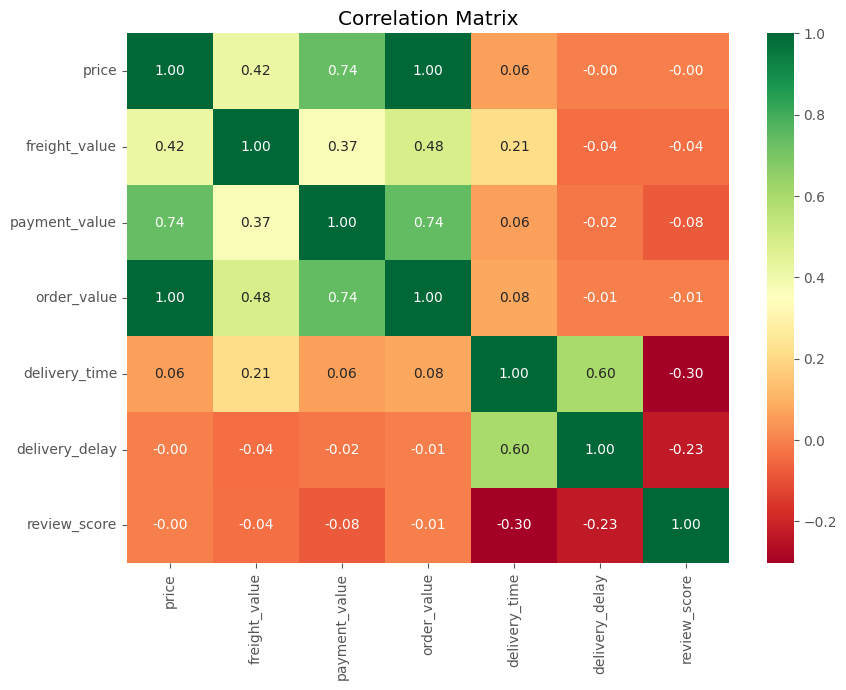

In [929]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Insight
The correlation analysis reveals several important relationships among business variables:
- **Price** and **Order Value** show an almost perfect positive correlation (**1.00**), indicating that product price is the primary contributor to the overall order value.
- **Payment Value** has a strong positive correlation with both **Price (0.74)** and **Order Value (0.74)**, suggesting that higher-priced orders generally result in higher customer payments.
- **Freight Value** has a moderate positive correlation with **Price (0.42)** and **Order Value (0.48)**, indicating that shipping costs tend to increase as the order value increases.
- **Delivery Time** and **Delivery Delay** are moderately positively correlated (**0.60**), meaning longer delivery durations are associated with a higher likelihood of delayed deliveries.
- **Review Score** has a moderate negative correlation with **Delivery Time (-0.30)** and **Delivery Delay (-0.23)**, suggesting that slower deliveries tend to reduce customer satisfaction, although the relationship is not particularly strong.

#### Business Recommendation
- Continue optimizing pricing strategies, as product price strongly influences total order value and customer payments.
- Improve logistics efficiency to reduce delivery time and delivery delays, which may contribute to higher customer satisfaction.
- Monitor freight costs carefully to ensure shipping charges remain competitive without negatively affecting profitability.
- Prioritize operational improvements rather than pricing adjustments when aiming to improve customer review scores.

### Executive Summary

#### Key Findings
1. Olist experienced consistent business growth throughout the observation period, with the highest monthly payment recorded in **November 2017**.
2. Monthly payment growth remained relatively stable after excluding incomplete months, indicating sustainable business expansion during 2017–2018.
3. The average order value (AOV) is approximately **R$206.95**, although the median order value is significantly lower, indicating a highly right-skewed transaction distribution.
4. Customer purchasing activity is concentrated on **weekdays**, with **Monday** generating the highest total payment.
5. Customer transactions peak around **15:00**, suggesting that most purchases occur during standard business hours.
6. **Credit Card** is the dominant payment method, contributing the majority of total transaction value.
7. **São Paulo (SP)** represents Olist's largest regional market in terms of both customer count and total payment.
8. RFM analysis indicates that **Loyal Customers** form the largest customer segment, while a considerable number of customers still require retention efforts.
9. The top **20% of customers contribute approximately 61.95% of total revenue**, indicating a relatively diversified customer revenue distribution.
10. Customer satisfaction tends to decrease as delivery time and delivery delays increase, highlighting the importance of logistics performance.

### Final Business Recommendations

#### Strategic Recommendations

##### 1. Marketing Strategy
- Increase promotional activities during historically high-performing periods, especially November.
- Schedule major campaigns on weekdays and during peak purchasing hours (13:00–16:00).

##### 2. Customer Retention
- Maintain loyalty programs for Champions and Loyal Customers.
- Launch personalized re-engagement campaigns for Need Attention and At Risk customers.

##### 3. Sales Growth
- Increase Average Order Value through cross-selling, upselling, and product bundling.
- Encourage repeat purchases by implementing personalized offers and reward programs.

##### 4. Operational Excellence
- Improve logistics performance to reduce delivery time and minimize delays.
- Strengthen customer service during peak transaction periods.

##### 5. Payment Strategy
- Continue optimizing the credit card payment experience while encouraging the adoption of alternative payment methods.

##### 6. Regional Expansion
- Continue strengthening Olist's presence in São Paulo, Rio de Janeiro, and Minas Gerais.
- Explore growth opportunities in regions with lower customer penetration through localized marketing strategies.

### Conclusion

This project demonstrates an end-to-end Business Analytics workflow using the Brazilian E-Commerce Public Dataset (Olist).

The analysis covers data preparation, exploratory data analysis, customer segmentation, revenue concentration analysis, customer lifetime value, and business-oriented recommendations. The insights generated from this project can support data-driven decision-making in marketing, sales, logistics, and customer relationship management.

The analytical dataset and findings also serve as the foundation for the interactive Power BI dashboard developed in the next stage of this project.